In [1]:
import sys
sys.path.append('../src')

# Look at the preprocessed spectrograms: class balance, examples, loudness, windows.
# Expects data/spectrograms/ produced by preprocess.py.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from preprocess import SR, HOP_LENGTH

SPEC_DIR = Path('../../data/spectrograms').resolve()
RNG = np.random.RandomState(42)

index = pd.read_csv(SPEC_DIR / 'index.csv', index_col=0)
genres = index['genre'].value_counts().index.tolist()

print(f'Tracks: {len(index)}, genres: {len(genres)}')
pd.crosstab(index['genre'], index['split'], margins=True).loc[genres + ['All']]

Tracks: 17477, genres: 14


split,test,training,validation,All
genre,,,,
Electronic,296,2403,300,2999
Rock,282,2407,308,2997
Experimental,225,1800,225,2250
Hip-Hop,220,1757,220,2197
Folk,152,1214,152,1518
Instrumental,174,1044,131,1349
Pop,119,945,122,1186
International,102,814,102,1018
Classical,62,495,62,619


Після препроцесингу лишилось 17477 треків з 17488 - 11 впало на відомих битих mp3 з FMA (список у failed.csv). Пропорції сплітів у кожному жанрі приблизно 80/10/10, тобто офіційний спліт після нашої фільтрації і капу не перекосився.

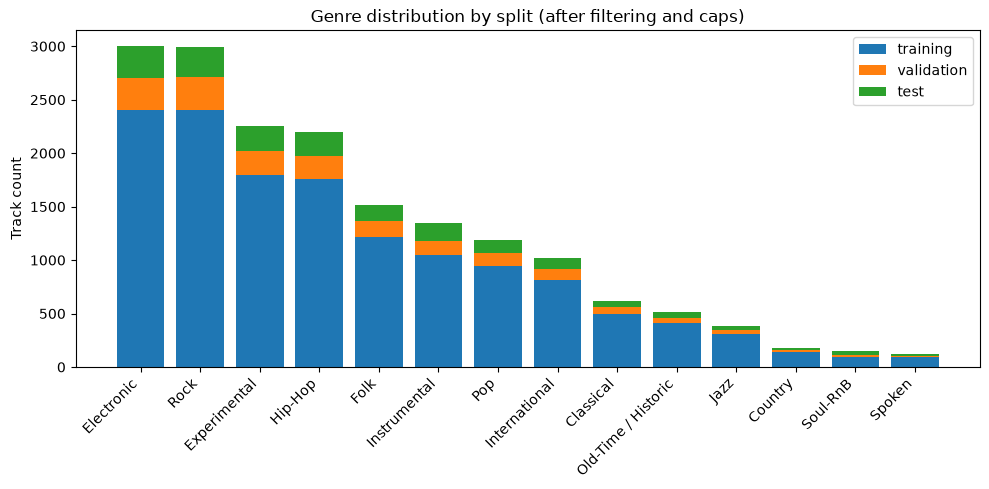

In [2]:
# Class balance per split: the official FMA split keeps proportions similar,
# so train/val/test all see the same imbalance.
counts = pd.crosstab(index['genre'], index['split']).loc[genres]

plt.figure(figsize=(10, 5))
bottom = np.zeros(len(counts))
for split in ['training', 'validation', 'test']:
    plt.bar(counts.index, counts[split], bottom=bottom, label=split)
    bottom += counts[split].values
plt.xticks(rotation=45, ha='right')
plt.ylabel('Track count')
plt.title('Genre distribution by split (after filtering and caps)')
plt.legend()
plt.tight_layout()
plt.show()

Дисбаланс лишається суттєвим: від ~3000 треків (Electronic, Rock) до 118 (Spoken). Вирішуємо це на етапі тренування - ваги класів у лоссі або WeightedRandomSampler, дані поки залишмо такі. Важливо, що пропорції однакові у всіх сплітах, тож метрики на val/test відображають ту саму задачу, що й train.

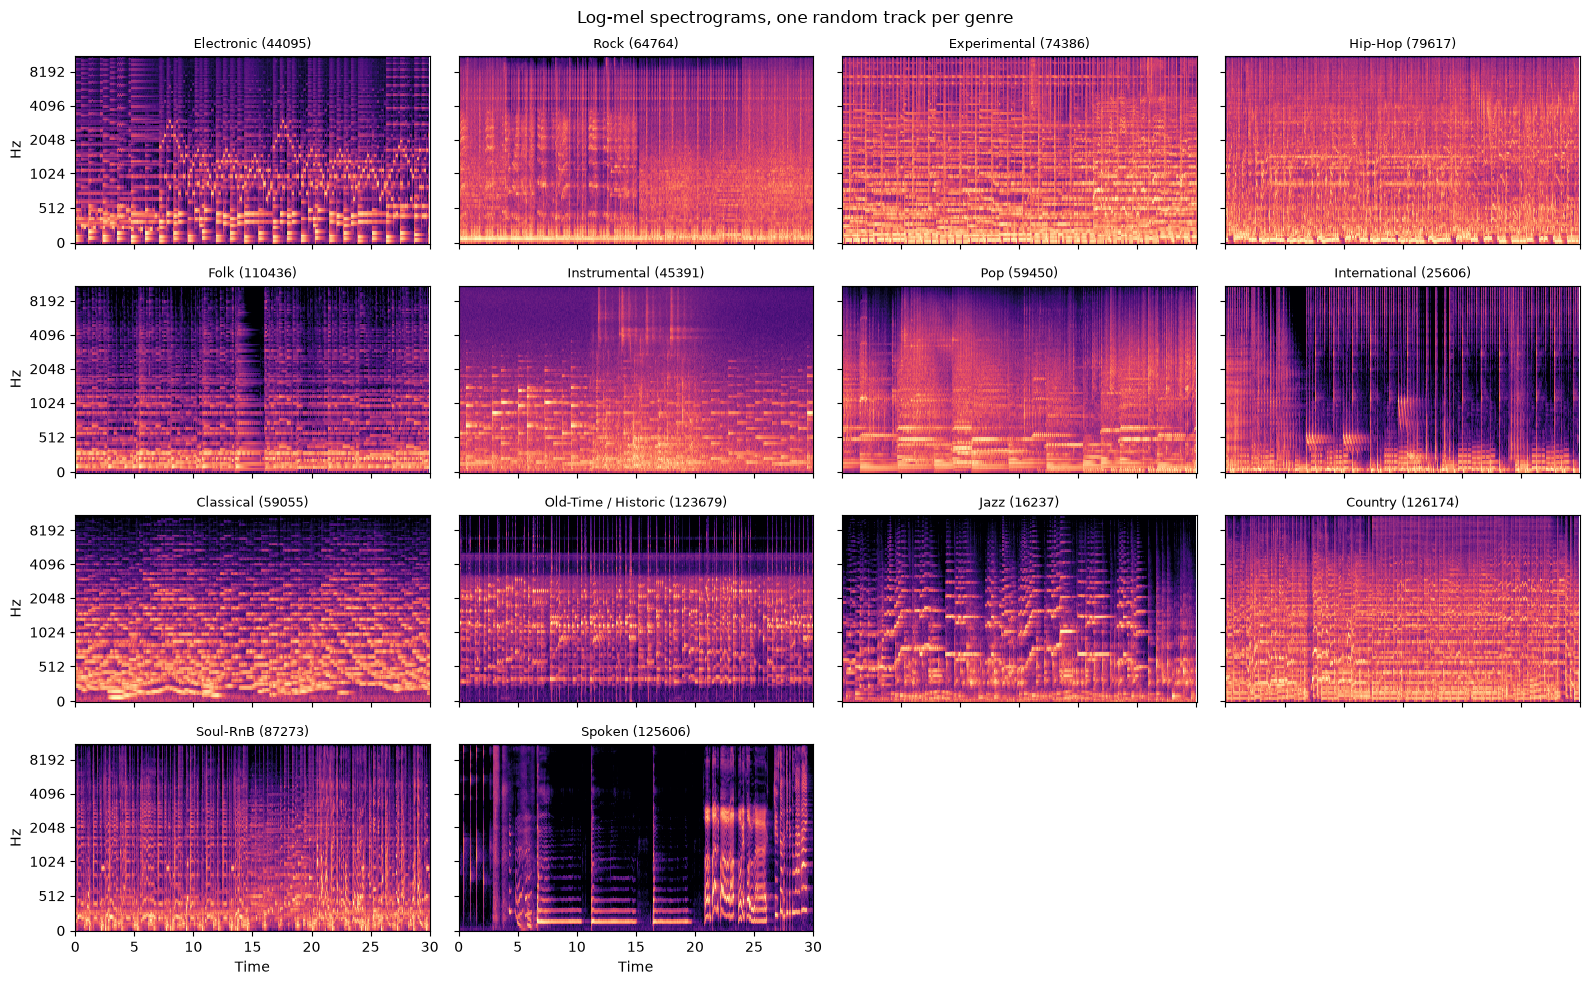

In [3]:
def load_spec(track_id):
    # float16 on disk, float32 for any math to avoid overflow
    return np.load(SPEC_DIR / f'{track_id:06d}.npy').astype(np.float32)

# One random track per genre, shared dB scale so genres are visually comparable
fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True, sharey=True)
for ax, genre in zip(axes.flat, genres):
    tid = RNG.choice(index[index['genre'] == genre].index)
    librosa.display.specshow(
        load_spec(tid), sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', vmin=-80, vmax=0, ax=ax,
    )
    ax.set_title(f'{genre} ({tid})', fontsize=9)
    ax.label_outer()
for ax in axes.flat[len(genres):]:
    ax.axis('off')
fig.suptitle('Log-mel spectrograms, one random track per genre')
fig.tight_layout()
plt.show()

Жанри помітно відрізняються навіть оком: у Classical розріджені гармоніки без ритмічної сітки, у Hip-Hop і Electronic щільний низ і регулярні вертикальні удари, у Spoken паузи і формантні смуги мови, Old-Time видає вузька смуга старого запису без верху. Якщо структура видна людині на спектрограмі, CNN буде за що вчитись.

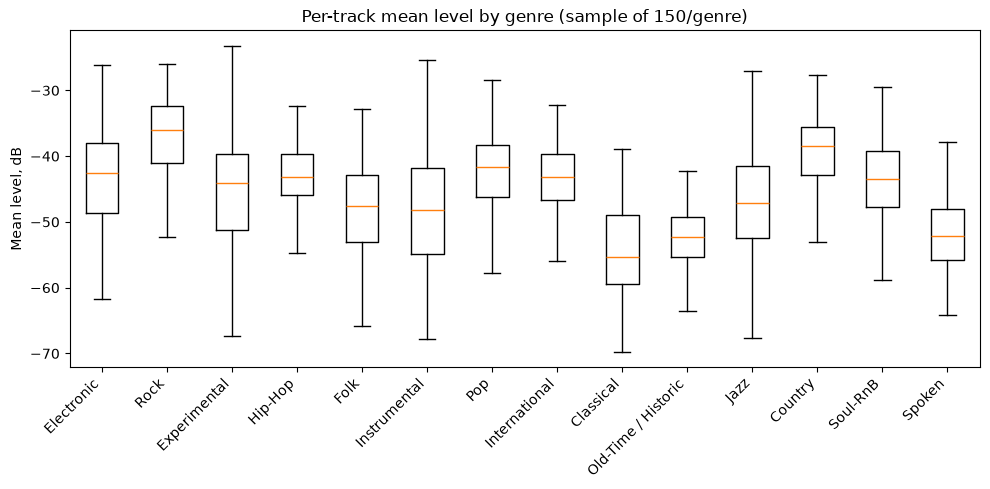

In [4]:
# Mean level per track: a crude 1-number feature, but already separates
# quiet acoustic genres from loud compressed ones.
SAMPLE_PER_GENRE = 150

means = {}
for genre in genres:
    ids = index[index['genre'] == genre].index
    ids = RNG.choice(ids, min(SAMPLE_PER_GENRE, len(ids)), replace=False)
    means[genre] = [load_spec(tid).mean() for tid in ids]

plt.figure(figsize=(10, 5))
plt.boxplot([means[g] for g in genres], tick_labels=genres, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean level, dB')
plt.title(f'Per-track mean level by genre (sample of {SAMPLE_PER_GENRE}/genre)')
plt.tight_layout()
plt.show()

Середній рівень сам по собі вже слабко розділяє жанри: акустичні й архівні (Classical, Old-Time, Spoken) тихіші за компресовані Rock/Country приблизно на 15 dB. Зворотний бік: модель може частково вивчити гучність замість тембру. При тренуванні варто спробувати нормалізацію кожного вікна окремо і порівняти якість.

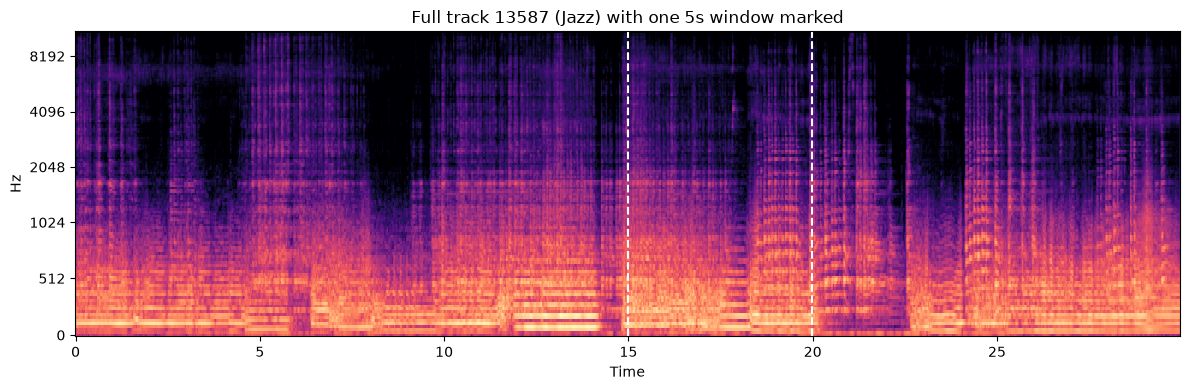

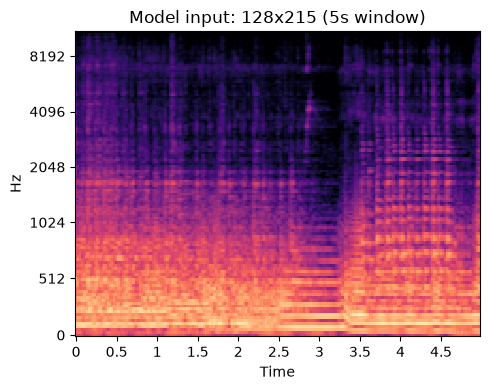

Window: 215 frames = 4.99s


In [5]:
# What the model will actually see: 5s windows cut from the full track.
WINDOW_S = 5.0
WINDOW_FRAMES = int(WINDOW_S * SR / HOP_LENGTH)

tid = RNG.choice(index[index['genre'] == 'Jazz'].index)
spec = load_spec(tid)
start = spec.shape[1] // 2

plt.figure(figsize=(12, 4))
librosa.display.specshow(spec, sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel', vmin=-80, vmax=0)
for x in (start, start + WINDOW_FRAMES):
    plt.axvline(x * HOP_LENGTH / SR, color='white', linestyle='--')
plt.title(f'Full track {tid} (Jazz) with one {WINDOW_S:.0f}s window marked')
plt.tight_layout()
plt.show()

window = spec[:, start:start + WINDOW_FRAMES]
plt.figure(figsize=(5, 4))
librosa.display.specshow(window, sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel', vmin=-80, vmax=0)
plt.title(f'Model input: {window.shape[0]}x{window.shape[1]} ({WINDOW_S:.0f}s window)')
plt.tight_layout()
plt.show()

print(f'Window: {WINDOW_FRAMES} frames = {WINDOW_FRAMES * HOP_LENGTH / SR:.2f}s')

Вхід моделі - вікно 128x215 (5 секунд). При тренуванні вікна нарізаються з кроком 2.5 с (50% перекриття), при інференсі крок налаштовується (типово 1 с). Нарізка відбувається на льоту в Dataset, тож розмір вікна можна міняти без перерахунку спектрограм. Мітка вікна успадковується від треку, агрегований результат по треку - середнє ймовірностей по вікнах.